In [8]:
# Import necessary packages
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, precision_recall_curve
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
# Load the dataset
# TODO Use train and test datasets. Will have to reuse data cleansing process from combined EDA notebook
#      https://github.com/BrettFX/DATA-602-Airline-Customer-Satisfaction/raw/refs/heads/prod/datasets/raw/train.csv
#      https://github.com/BrettFX/DATA-602-Airline-Customer-Satisfaction/raw/refs/heads/prod/datasets/raw/test.csv
url = 'https://raw.githubusercontent.com/BrettFX/DATA-602-Airline-Customer-Satisfaction/refs/heads/prod/datasets/clean/cleaned_airline_passenger_satisfaction.csv'
data = pd.read_csv(url)

# Convert categorical columns to dummy variables
X = pd.get_dummies(data.drop(columns=['SATISFACTION']), drop_first=True)
y = data['SATISFACTION'].apply(lambda x: 1 if x == 'satisfied' else 0)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Impute missing values with the median
imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Scale the imputed data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

In [15]:
# Initialize and train the SVM model
svc_model = SVC(random_state=42, probability=True)
svc_model.fit(X_train_scaled, y_train)

# Predictions and evaluation
y_pred = svc_model.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9413010007698229
Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.96      0.95      2945
           1       0.94      0.92      0.93      2251

    accuracy                           0.94      5196
   macro avg       0.94      0.94      0.94      5196
weighted avg       0.94      0.94      0.94      5196



In [ ]:
# TODO Try training new SVM with MinMaxScaler to compare with StandardScaler


In [16]:
# Hyperparameter tuning with Grid Search
param_grid = {'C': [0.1, 1, 10], 'gamma': ['scale', 'auto'], 'kernel': ['rbf', 'linear']}
grid_search = GridSearchCV(SVC(random_state=42), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

# Best model and performance
print("Best Parameters from Grid Search:", grid_search.best_params_)
print("Best Grid Search Accuracy:", grid_search.best_score_)

# Evaluate the best model
y_pred_grid = grid_search.best_estimator_.predict(X_test_scaled)
print("Grid Search Test Accuracy:", accuracy_score(y_test, y_pred_grid))
print("Classification Report for Grid Search:\n", classification_report(y_test, y_pred_grid))

Best Parameters from Grid Search: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best Grid Search Accuracy: 0.9454282964388835
Grid Search Test Accuracy: 0.9474595842956121
Classification Report for Grid Search:
               precision    recall  f1-score   support

           0       0.95      0.96      0.95      2945
           1       0.94      0.93      0.94      2251

    accuracy                           0.95      5196
   macro avg       0.95      0.95      0.95      5196
weighted avg       0.95      0.95      0.95      5196



In [20]:
# Manual Hyperparameter Tuning
tuned_params = [
    {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'},
    {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'},
    {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}
]

best_accuracy = 0
best_params = {}

for params in tuned_params:
    # Initialize SVM with specific parameters
    svc_model = SVC(C=params['C'], gamma=params['gamma'], kernel=params['kernel'], random_state=42, probability=True)
    svc_model.fit(X_train_scaled, y_train)
    
    # Evaluate on test data
    y_pred = svc_model.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Parameters: {params} -> Accuracy: {accuracy:.4f}")
    
    # Track best model
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_params = params

print(f"Best Manual Tuning Parameters: {best_params} with Accuracy: {best_accuracy:.4f}")

Parameters: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'} -> Accuracy: 0.8714
Parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'} -> Accuracy: 0.9413
Parameters: {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'} -> Accuracy: 0.9475
Best Manual Tuning Parameters: {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'} with Accuracy: 0.9475


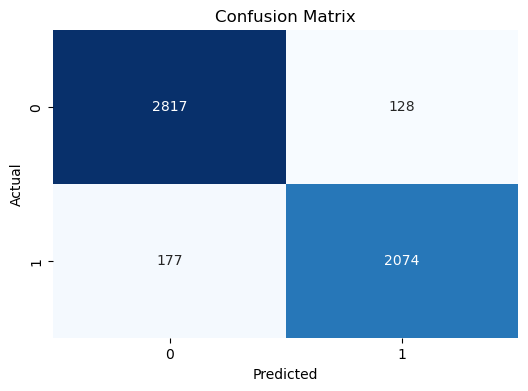

In [17]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

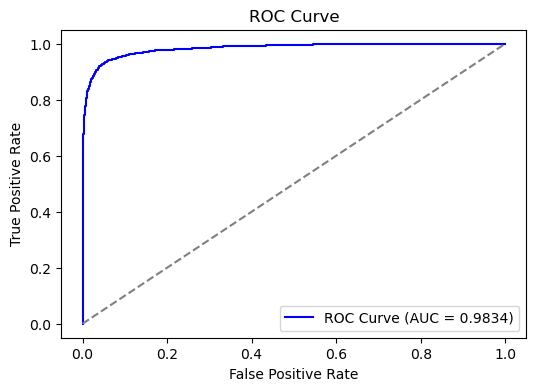

In [18]:
# ROC Curve
y_pred_prob = svc_model.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc_score(y_test, y_pred_prob):.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='best')
plt.show()

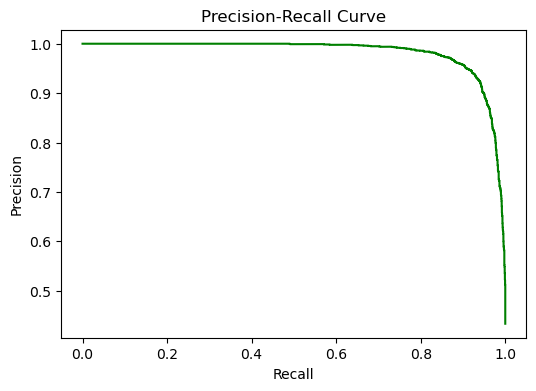

In [19]:
# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_prob)
plt.figure(figsize=(6, 4))
plt.plot(recall, precision, color='green')
plt.title('Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.show()

# Insights:
# - Inflight service features like wifi and entertainment correlate positively with satisfaction.
# - SVM model effectively predicts satisfied vs. dissatisfied passengers.
# - Age distributions show slight differences in satisfaction across age groups, suggesting varied expectations.

In [ ]:
# Future Work:
# - Encountered categorical data error; solved by one-hot encoding.
# - Missing values led to errors, handled by imputing with the median.
# - Future steps: Try other models like random forests, tune more hyperparameters, and test on specific traveler segments.